### Univariate activation analysis on preprocessed fMRI data (fMRIPrep-derivatives)

In [ ]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import to_rgba
from nilearn.image import index_img, load_img, new_img_like, resample_to_img
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel

warnings.filterwarnings("ignore")

In [ ]:
PATHs = {
    "data": "../data",
    "result": "../results"
    }

In [ ]:
from utils import AAL3_label2name
from utils import set_log, cluster_correction, plot_map, load_aal3

CONDITIONs = ["Joyfulrelaxation", "Sadness", "Enthusiasm", "Anger"]
logger = set_log("univ_pattern.log", os.path.join(PATHs["result"], "logs"), stream_handler = False)

#### 1. First Level Analysis

In [ ]:
def load_data(sub_id, task, run_id):
    func_img = os.path.join(PATHs["data"], "bids", "derivatives", f"sub-{sub_id:02d}", "func",
                            f"sub-{sub_id:02d}_task-{task}_run-{run_id:02d}_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz")
    mask_img = os.path.join(PATHs["data"], "bids", "derivatives", f"sub-{sub_id:02d}", "func",
                            f"sub-{sub_id:02d}_task-{task}_run-{run_id:02d}_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz")
    events = pd.read_csv(os.path.join(PATHs["data"], "design", "task-events.tsv"), sep = '\t')[["onset", "duration", "trial_type"]]
    return func_img, mask_img, events

In [ ]:
# build confounds derived from fmriprep (motion, physiological, motion outlier)
# discard the first and last a few volumes
def build_confounds(sub_id, task, run_id, trim_volumes = 5):
    confounds_tsv = os.path.join(PATHs["data"], "bids", "derivatives", f"sub-{sub_id:02d}", "func",
                                 f"sub-{sub_id:02d}_task-{task}_run-{run_id:02d}_desc-confounds_timeseries.tsv")
    confounds = pd.read_csv(confounds_tsv, sep = '\t')
    if task == "NF": confounds = confounds.iloc[20:].reset_index(drop = True)
    # Confounds to remove the first and last a few volumes
    discard_volumes = np.ones(confounds.shape[0])
    discard_volumes[trim_volumes: -trim_volumes] = 0
    discard_volumes = pd.DataFrame(discard_volumes, columns = ["discard_volumes"])
    # Motion confounds
    motion_confounds = confounds[["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]].fillna(0)
    # Physiological confounds
    a_comp_cor = [f'a_comp_cor_{i:02d}' for i in range(1, 6)]
    physio_confounds = confounds[["csf", "white_matter"] + a_comp_cor].fillna(0)
    # Motion outlier confounds
    motion_outlier_cols = [col for col in confounds.columns if "motion_outlier" in col]
    if motion_outlier_cols:
        outlier_confounds = confounds[motion_outlier_cols]
        confounds_df = pd.concat([motion_confounds, physio_confounds, outlier_confounds, discard_volumes], axis = 1)
    else:
        confounds_df = pd.concat([motion_confounds, physio_confounds, discard_volumes], axis = 1)
    return confounds_df

In [6]:
# first-level analysis for each run (contrast: task vs rest)
# uncorrected voxel-wise threshold (z-score, p < 0.05), cluster-level threshold (p < 0.05)
def first_level_analysis(sub_id, task, run_id, voxel_thresh = 2.576, cluster_thresh = 0.05):
    logger.info(f"Running first-level analysis for sub-{sub_id:02d}_task-{task}_run-{run_id:02d}")
    stat_path = os.path.join(PATHs["result"], "univ_stats", f'sub-{sub_id:02d}_task-{task}_run-{run_id:02d}_task-vs-rest.nii.gz')
    if os.path.exists(stat_path):
        logger.info(f"First-level analysis for sub-{sub_id:02d}_task-{task}_run-{run_id:02d} already exists")
        return
    func_img, mask_img, events = load_data(sub_id, task, run_id)
    if not os.path.exists(func_img): 
        logger.info(f"No data available for sub-{sub_id:02d}_task-{task}_run-{run_id:02d}")
        return                             # Skip if no data available
    if task == "NF": func_img = index_img(func_img, slice(20, None))    # Skip first 20 volumes for NF task
    confounds = build_confounds(sub_id, task, run_id)
    # fit first-level model
    first_level_model = FirstLevelModel(
        t_r = 1.0, slice_time_ref = 0.5, hrf_model = "spm", drift_model = 'cosine',
        high_pass = 1/128, smoothing_fwhm = 6.0, noise_model = 'ar1', standardize = True, mask_img = mask_img
    )
    first_level_model.fit(func_img, events = events, confounds = confounds)
    # build contrast matrix (task vs rest)
    design_matrix = first_level_model.design_matrices_[0]
    contrast_matrix = np.eye(design_matrix.shape[1])
    basic_contrasts = {column: contrast_matrix[i] for i, column in enumerate(design_matrix.columns)}
    task_vs_rest_contrast = basic_contrasts["task"] - basic_contrasts["rest"]
    # compute contrast map and apply cluster-level correction
    contrast_map = first_level_model.compute_contrast(task_vs_rest_contrast, output_type = 'z_score')
    corrected_map = cluster_correction(contrast_map, voxel_thresh = voxel_thresh, cluster_thresh = cluster_thresh, logger = logger)
    corrected_map.to_filename(stat_path)

#### 2. Second Level Analysis

In [7]:
# second-level analysis for each run (one-sample t-test)
# uncorrected voxel-wise threshold (t-value,p < 0.05), cluster-level threshold (p < 0.05)
def second_level_analysis(task, run_id, total_sub_num = 27, voxel_thresh = 2.704, cluster_thresh = 0.05, desc = ""):
    logger.info(f"Running second-level analysis for task-{task}_run-{run_id:02d}")
    stat_path = os.path.join(PATHs["result"], "univ_stats", f'group_task-{task}_run-{run_id:02d}_task-vs-rest{desc}.nii.gz')
    fig_path = os.path.join(PATHs["result"], "figures", f'group_task-{task}_run-{run_id:02d}_task-vs-rest{desc}.png')
    if not os.path.exists(stat_path):
        # first-level analysis for each subject
        for sub_id in range(1, total_sub_num+1): first_level_analysis(sub_id, task, run_id)
        # load group contrast maps according to the task and run
        contrast_files = glob.glob(os.path.join(PATHs["result"], "univ_stats", f'sub*task-{task}_run-{run_id:02d}_task-vs-rest.nii.gz'))
        if task == "NF":        # special case: run-02 from sub-01 is for sadness instead of joyfulrelaxation
            if run_id < 3: contrast_files = [f for f in contrast_files if not "sub-01" in f]
            else: contrast_files.append(os.path.join(PATHs["result"], "univ_stats", 'sub-01_task-NF_run-02_task-vs-rest.nii.gz'))
        elif len(desc) > 0:     # exclude some subjects in localizer run for comparison with NF run 
            if run_id == 1: excluded_subs = ["sub-01", "sub-13", "sub-24"]
            else: excluded_subs = ["sub-04", "sub-05", "sub-06", "sub-07", "sub-13", "sub-15", "sub-18", \
                "sub-20", "sub-22", "sub-23", "sub-24", "sub-26", "sub-27"]
            contrast_files = [f for f in contrast_files if not any(sub in f for sub in excluded_subs)]
        contrast_imgs = [nib.load(f) for f in contrast_files]
        # fit second-level model
        design_matrix = pd.DataFrame(np.ones((len(contrast_imgs), 1)), columns = ['Intercept'])
        second_level_model = SecondLevelModel(mask_img = load_img(os.path.join(PATHs["data"], "design", "voi_mask_mni.nii.gz")))
        second_level_model.fit(contrast_imgs, design_matrix = design_matrix)
        # compute group contrast map and apply cluster-level correction
        group_map = second_level_model.compute_contrast(output_type = 'stat')
        group_map = cluster_correction(group_map, voxel_thresh = voxel_thresh, cluster_thresh = cluster_thresh)
        group_map.to_filename(stat_path)
    logger.info(f"Done second-level analysis for task-{task}_run-{run_id:02d}")
    # plot group contrast map
    group_map = nib.load(stat_path)
    plot_map(group_map, fig_path)

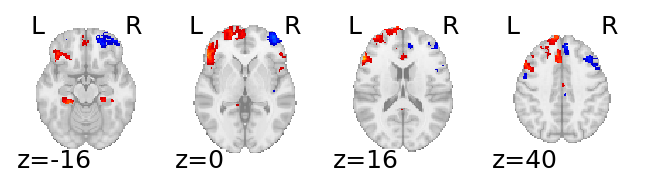

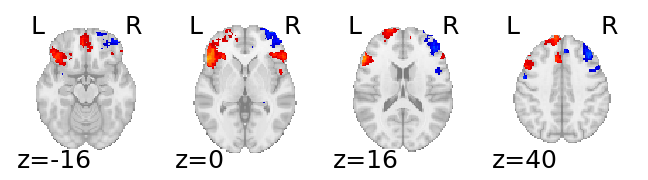

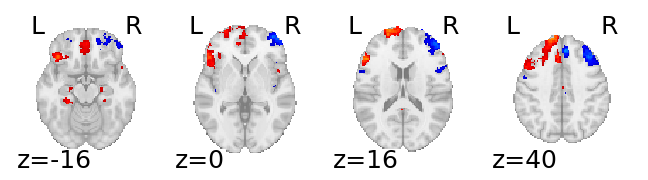

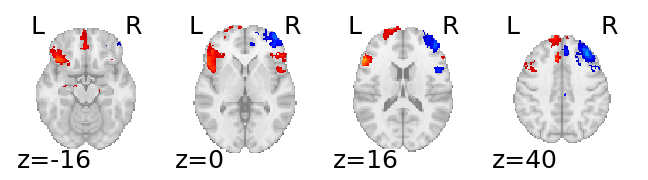

In [8]:
# Localizer data analysis (N = 27)
for run_id in range(1, 5):
    second_level_analysis("localizer", run_id)

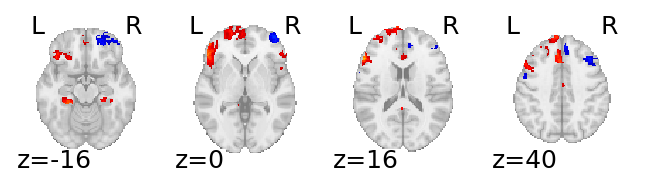

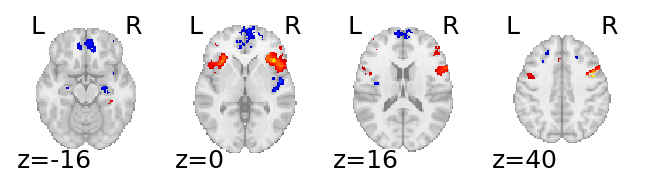

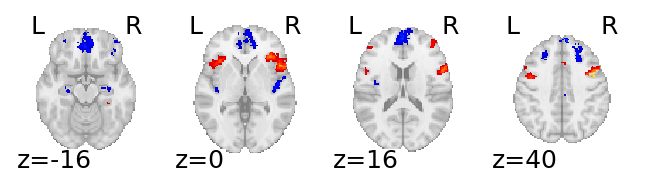

In [9]:
# NF data analysis (Joyfulrelaxation, N = 24)
second_level_analysis("localizer", run_id = 1, desc = "_compare-NF")
for run_id in range(1, 3):
    second_level_analysis("NF", run_id)

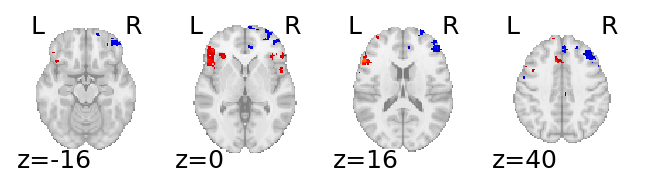

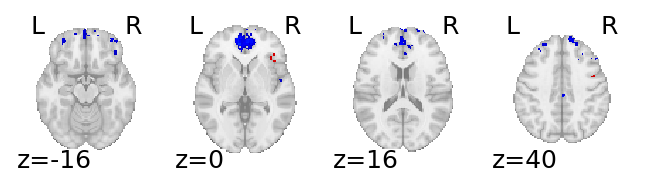

In [10]:
# NF data analysis (Sadness, N = 14)
second_level_analysis("localizer", run_id = 2, desc = "_compare-NF")
second_level_analysis("NF", run_id = 3)

#### 3. ROI Analysis

In [11]:
# Locate ROIs in predefined VOI (regions with overlap ratio > 0.5)
def voi2roi(overlap_threshold = 0.5):
    logger.info("Locating ROIs in predefined VOI...")
    aal3_img, aal3_data, _, aal3_id2label, _ = load_aal3(os.path.join(PATHs["data"], "templates", "AAL3v1.nii"))
    voi_img = nib.load(os.path.join(PATHs["data"], "design", "voi_mask_mni.nii.gz"))
    voi_data = voi_img.get_fdata()
    assert np.array_equal(aal3_img.affine, voi_img.affine)
    rois_in_voi = []
    with open(os.path.join(PATHs["result"], "univ_stats", "ROI_in_VOI.txt"), 'w') as outp:
        aal_indices = np.unique(aal3_data)
        aal_indices = aal_indices[aal_indices != 0]  # skip background
        for idx in aal_indices:
            roi_mask = aal3_data == idx
            total_voxels = np.sum(roi_mask)
            masked_voxels = np.sum(roi_mask[voi_data == 1])
            roi_label = aal3_id2label[idx]
            masked_ratio = masked_voxels/total_voxels
            if masked_ratio > overlap_threshold:
                outp.write(f"Region {roi_label} (id-{int(idx)}): {masked_voxels}/{total_voxels} = {masked_ratio}\n")
                rois_in_voi.append(roi_label)
    split_rois_in_voi = [roi_label for roi_label in rois_in_voi if roi_label.endswith("L")]
    split_rois_in_voi.extend([roi_label for roi_label in rois_in_voi if roi_label.endswith("R")])
    with open(os.path.join(PATHs["result"], "univ_stats", "ROI_in_VOI.txt"), 'r') as inp:
        for line in inp.readlines(): print(line)
    return split_rois_in_voi

In [12]:
# Select top-performed ROIs for main visualization
# Order ROIs based on the average activities of each ROI across runs
def select_top_roi(rois_in_voi, top_num = 10, task = "localizer", run_num = 4):
    logger.info("Selecting top-performing ROIs...")
    aal3_img, aal3_data, _, _, aal3_label2id = load_aal3(os.path.join(PATHs["data"], "templates", "AAL3v1.nii"))
    activities = {roi_label: [] for roi_label in rois_in_voi}
    for run_id in range(1, run_num+1):
        stat_path = os.path.join(PATHs["result"], "univ_stats", f'group_task-{task}_run-{run_id:02d}_task-vs-rest.nii.gz')
        group_img = nib.load(stat_path)
        assert np.array_equal(aal3_img.affine, group_img.affine)
        group_data = group_img.get_fdata()
        for roi_label in rois_in_voi:
            roi_idx = aal3_label2id[roi_label]
            activities[roi_label].append(np.absolute(np.mean(group_data[aal3_data == roi_idx])))
    with open(os.path.join(PATHs["result"], "univ_stats", "rois_activities.json"), "w", encoding = "utf-8") as outp:
        json.dump(activities, outp, indent = 4)
    mean_activities = {roi_label: np.mean(np.array(activities[roi_label])) for roi_label in rois_in_voi}
    sorted_rois = list(dict(sorted(mean_activities.items(), key = lambda item: item[1], reverse = True)).keys())
    top_rois_L = [roi_label for roi_label in sorted_rois if roi_label.endswith("L")][:top_num]
    other_rois_L = [roi_label for roi_label in sorted_rois if roi_label.endswith("L")][top_num:]
    top_rois_R = [roi_label for roi_label in sorted_rois if roi_label.endswith("R")][:top_num]
    other_rois_R = [roi_label for roi_label in sorted_rois if roi_label.endswith("R")][top_num:]
    return top_rois_L, other_rois_L, top_rois_R, other_rois_R

In [13]:
# Build ROI mask for each ROI
def build_roi_mask(rois_in_voi):
    aal3_img, aal3_data, _, _, aal3_label2id = load_aal3(os.path.join(PATHs["data"], "templates", "AAL3v1.nii"))
    roi_mask = np.zeros_like(aal3_data)
    for roi_idx, roi_label in enumerate(rois_in_voi):
        roi_value = aal3_label2id[roi_label]
        roi_mask[aal3_data == roi_value] = roi_idx+1
    roi_mask_img = new_img_like(aal3_img, roi_mask)
    roi_mask_img.to_filename(os.path.join(PATHs["result"], "univ_stats", "selected_aal3_rois.nii.gz"))

In [14]:
def plot_bar4roi(ax, x_positions, offset, bar_colors, scatter_colors, all_rois, target_rois):
    handles = []
    results_dict = {roi_label: {} for (roi_label, _) in all_rois}
    for run_id in range(1, 5):
        contrast_files = [os.path.join(PATHs["result"], "univ_stats", f'sub-{sub_id:02d}_task-localizer_run-{run_id:02d}_task-vs-rest.nii.gz') for sub_id in range(1, 28)]
        contrast_imgs = np.stack([load_img(f).get_fdata().flatten() for f in contrast_files if "sub-08" not in f], axis = 0)
        roi_mask_file = os.path.join(PATHs["result"], "univ_stats", "selected_aal3_rois.nii.gz")
        roi_mask_img = resample_to_img(roi_mask_file, contrast_files[0], interpolation = "nearest")
        plot_roi_idx = 0
        for roi_label, roi_mask_idx in all_rois:
            contrast_mask = roi_mask_img.get_fdata().flatten() == roi_mask_idx
            roi_contrast = contrast_imgs[:, contrast_mask]
            roi_mean = roi_contrast.mean(axis = 1)
            results_dict[roi_label][CONDITIONs[run_id-1]] = np.nan_to_num(roi_mean)
            if roi_label not in target_rois: continue
            curr_err = np.std(roi_mean)
            ax.vlines(x_positions[plot_roi_idx]+offset[run_id-1], ymin = np.min(roi_mean), zorder = 1,
                      ymax = np.mean(roi_mean)-curr_err, color = bar_colors[plot_roi_idx], linewidth = 0.8)
            ax.vlines(x_positions[plot_roi_idx]+offset[run_id-1], ymin = np.mean(roi_mean)+curr_err, zorder = 1,
                      ymax = np.max(roi_mean), color=bar_colors[plot_roi_idx], linewidth = 0.8)
            ax.errorbar(x_positions[plot_roi_idx]+offset[run_id-1], np.mean(roi_mean), yerr = curr_err, zorder = 2,
                        fmt = 'none', color = bar_colors[plot_roi_idx], capsize = 0, elinewidth = 5)
            handle = ax.scatter(x_positions[plot_roi_idx]+offset[run_id-1], np.mean(roi_mean), color = scatter_colors[run_id%2],
                                edgecolor = 'none', s = 25, marker = 'o' if run_id < 3 else '^', zorder = 3)
            if plot_roi_idx == 0: handles.append(handle)
            plot_roi_idx += 1
    return results_dict, handles

In [15]:
# Perform t-test between conditions and then FDR-corrected across ROIs
# (0, 1): joyful relaxation vs sadness, (0, 2): joyful relaxation vs enthusiasm
# (1, 3): sadness vs anger, (2, 3): enthusiasm vs anger
def compare_between_condition(results_dict, all_rois, target_indices):
    p_values = {(0, 1): [], (0, 2): [], (1, 3): [], (2, 3): []}
    for cond_i, cond_j in p_values.keys():
        for roi_label, _ in all_rois:
            array_i, array_j = np.array(results_dict[roi_label][CONDITIONs[cond_i]]), np.array(results_dict[roi_label][CONDITIONs[cond_j]])
            _, pval = stats.ttest_rel(array_i, array_j)
            if np.nan_to_num(pval) == 0.: pval = -1
            p_values[(cond_i, cond_j)].append(pval)
        mask = np.array(p_values[(cond_i, cond_j)]) != -1
        pvals_before = np.array(p_values[(cond_i, cond_j)])[mask]
        _, pvals_corrected, _, _ = multipletests(pvals_before, alpha = 0.05, method = 'fdr_bh')
        pvals_after = np.ones(len(p_values[(cond_i, cond_j)]))
        pvals_after[mask] = pvals_corrected
        p_values[(cond_i, cond_j)] = [pvals_after[idx] for idx in target_indices]
    return p_values

In [16]:
def plot_markers(results_dict, ax, x_positions, offset, target_rois, p_values):
    for roi_idx, roi_label in enumerate(target_rois):
        for position, cond_i, cond_j in [("bottom", 0, 1), ("top", 0, 2), ("top", 1, 3), ("bottom", 2, 3)]:
            array_i, array_j = np.array(results_dict[roi_label][CONDITIONs[cond_i]]), np.array(results_dict[roi_label][CONDITIONs[cond_j]])
            pval = p_values[(cond_i, cond_j)][roi_idx]
            if pval < 0.05:
                if pval < 0.001: pval_marker = "***"
                elif pval < 0.01: pval_marker = "**"
                else: pval_marker = "*"
                x1, x2 = x_positions[roi_idx]+offset[cond_i], x_positions[roi_idx]+offset[cond_j]
                if position == "top":
                    y = max(np.concatenate([array_i, array_j])) + 0.3  # Above highest boxplot
                    text_y = y + 0.05
                    ax.plot([x1, x1, x2, x2], [y, y + 0.05, y + 0.05, y], color = "black", linewidth = 0.8)
                else:
                    y = min(np.concatenate([array_i, array_j])) - 0.3  # Below lowest boxplot
                    text_y = y - 0.65
                    ax.plot([x1, x1, x2, x2], [y, y - 0.05, y - 0.05, y], color = "black", linewidth = 0.8)
                ax.text((x1 + x2) / 2, text_y, pval_marker, ha = "center", fontsize = 10)#, fontweight = "bold")

In [17]:
# Main function for ROI analysis, comparing differences between conditions
def roi_analysis(rois_in_voi, target_rois, desc, alpha = 0.6):
    all_rois = [(roi_label, idx+1) for idx, roi_label in enumerate(rois_in_voi)]            # (roi_label, roi_mask_num)
    target_indices = [idx for idx, roi_label in enumerate(rois_in_voi) if roi_label in target_rois]
    num_of_rois = len(target_rois)
    fig, ax = plt.subplots(figsize = (5, 4.5))
    x_positions = np.arange(0, num_of_rois/2, 0.5)
    offset = [-0.2, -0.1, 0., 0.1]
    scatter_colors = ["navy", "crimson"]
    bar_colors = [to_rgba(c, alpha = alpha if idx < 4 or idx > 6 else 1.) for idx, c in enumerate(plt.get_cmap("RdYlBu")(np.linspace(0, 1, 10)))]
    logger.info("Computing univariate performance for ROIs across conditions...")
    results_dict, handles = plot_bar4roi(ax, x_positions, offset, bar_colors, scatter_colors, all_rois, target_rois)
    ax.set_xticks(np.arange(0, num_of_rois/2, 0.5))
    ax.set_xticklabels([AAL3_label2name[roi[:-2]] for roi in target_rois], fontdict = {'fontsize': 11}, rotation = 40, ha = "right") 
    ax.legend(handles, CONDITIONs, loc = "upper center", fontsize = 12, ncol = 2, framealpha = 0.4)
    p_values = compare_between_condition(results_dict, all_rois, target_indices)
    plot_markers(results_dict, ax, x_positions, offset, target_rois, p_values)     
    if desc == "L-top": 
        ax.set_ylim(-5, 10)
        ax.set_yticks(np.arange(-4, 9, 2))
        ax.set_yticklabels(np.arange(-4, 9, 2), fontsize = 15)
    elif desc == "R-top":
        ax.set_ylim(-6, 6)
        ax.set_yticks(np.arange(-6, 7, 2))
        ax.set_yticklabels(np.arange(-6, 7, 2), fontsize = 15)
    elif desc == "L-other":
        ax.set_ylim(-4, 7)
        ax.set_yticklabels(np.arange(-4, 7, 2), fontsize = 15)
    elif desc == "R-other":
        ax.set_ylim(-4, 6)
        ax.set_yticklabels(np.arange(-4, 6, 2), fontsize = 15)
    ax.grid(axis = "y", linestyle = '--', linewidth = 0.5, color = 'gray', alpha = 0.25)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", f"roi-analysis_{desc}.png"), dpi = 300)
    # plt.close()

In [18]:
rois_in_voi = voi2roi()
build_roi_mask(rois_in_voi)
top_rois_L, other_rois_L, top_rois_R, other_rois_R = select_top_roi(rois_in_voi)

Region Frontal_Sup_2_L (id-3): 3446/4870 = 0.7075975359342915

Region Frontal_Sup_2_R (id-4): 3332/5126 = 0.6500195083886071

Region Frontal_Mid_2_L (id-5): 3354/4507 = 0.7441757266474374

Region Frontal_Mid_2_R (id-6): 3639/4860 = 0.7487654320987654

Region Frontal_Inf_Oper_L (id-7): 824/1038 = 0.7938342967244701

Region Frontal_Inf_Oper_R (id-8): 1096/1399 = 0.7834167262330236

Region Frontal_Inf_Tri_L (id-9): 2049/2529 = 0.8102016607354685

Region Frontal_Inf_Tri_R (id-10): 1484/2151 = 0.6899116689911668

Region Frontal_Inf_Orb_2_L (id-11): 683/814 = 0.8390663390663391

Region Frontal_Inf_Orb_2_R (id-12): 609/874 = 0.6967963386727689

Region Olfactory_L (id-17): 208/291 = 0.7147766323024055

Region Olfactory_R (id-18): 224/288 = 0.7777777777777778

Region Frontal_Sup_Medial_L (id-19): 2155/2992 = 0.7202540106951871

Region Frontal_Sup_Medial_R (id-20): 1667/2134 = 0.7811621368322399

Region Frontal_Med_Orb_L (id-21): 603/719 = 0.8386648122392212

Region Frontal_Med_Orb_R (id-22): 76

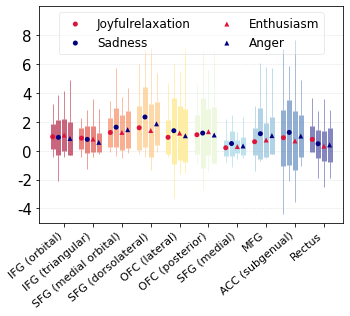

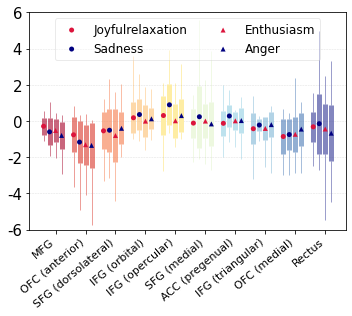

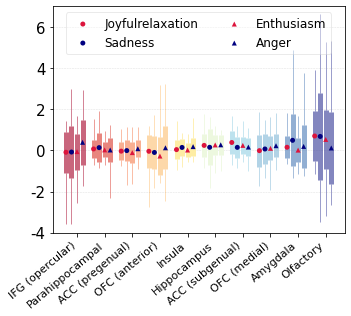

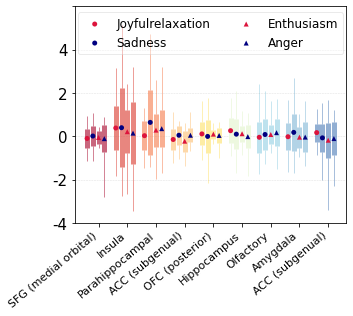

In [19]:
roi_analysis(rois_in_voi, top_rois_L, desc = "L-top")
roi_analysis(rois_in_voi, top_rois_R, desc = "R-top")
roi_analysis(rois_in_voi, other_rois_L, desc = "L-other")
roi_analysis(rois_in_voi, other_rois_R, desc = "R-other")